# Swin Transformer

> **Note:**
>
> This notebook implements an **educational version of the Swin Transformer** that closely follows the main ideas presented in the original paper while remaining concise and easy to understand.
>
> ### Implemented
> - ✅ Patch Embedding using `Conv2D`
> - ✅ Hierarchical feature representation
> - ✅ Window-based Multi-Head Self Attention (W-MSA)
> - ✅ Shifted Window Self Attention (SW-MSA)
> - ✅ Layer Normalization
> - ✅ Residual (Skip) Connections
> - ✅ Feed Forward Network (MLP)
> - ✅ Patch Merging
> - ✅ Multi-stage Swin architecture for image classification
>
> ### Not Implemented
> - ❌ Relative Position Bias
> - ❌ Attention Mask for Shifted Windows
> - ❌ Stochastic Depth (DropPath)
> - ❌ Four-stage Swin-T architecture with depths `[2, 2, 6, 2]`
> - ❌ Official weight initialization and training schedule
>
> <br/>
>
> **Original Paper:** *Swin Transformer: Hierarchical Vision Transformer Using Shifted Windows* (Liu et al., ICCV 2021)  
> https://arxiv.org/abs/2103.14030
>
> <br/>
>
> **Microsoft Research Implementation:**  
> https://github.com/microsoft/Swin-Transformer

## Importing the libraries

In [1]:
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix

## Loading CIFAR10 dataset from kaggle

In [2]:
path = kagglehub.dataset_download("swaroopkml/cifar10-pngs-in-folders")
print("Path to dataset files:", path)

100%|██████████| 140M/140M [00:00<00:00, 232MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/swaroopkml/cifar10-pngs-in-folders/versions/1


In [3]:
train_dir = os.path.join(path, "cifar10", "cifar10", "train")
test_dir = os.path.join(path, "cifar10","cifar10", "test")

In [4]:
IMG_SIZE = (32, 32)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size = IMG_SIZE,
    batch_size = None,
    shuffle = True
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size = IMG_SIZE,
    batch_size = None,
    shuffle = False
)

Found 50000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


## Converting into numpy array

In [5]:
X_train = []
y_train = []

for image, label in train_dataset:
    X_train.append(image.numpy())
    y_train.append(label.numpy())

X_train = np.array(X_train)
y_train = np.array(y_train)

In [6]:
X_test = []
y_test = []

for image, label in test_dataset:
    X_test.append(image.numpy())
    y_test.append(label.numpy())

X_test = np.array(X_test)
y_test = np.array(y_test)

In [7]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000,)
(10000, 32, 32, 3)
(10000,)


## Normalizing the images

In [8]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

## Defining Class Names

In [9]:
classes = ["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship","Truck"]

## Visualising the images

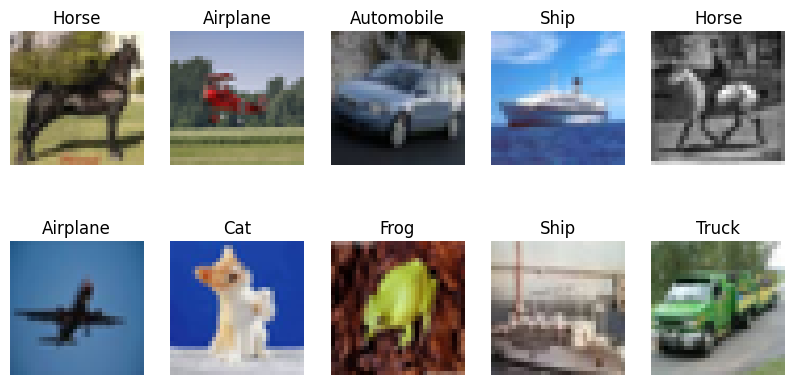

In [10]:
plt.figure(figsize = (10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(classes[y_train[i]])
    plt.axis("off")

plt.show()

## Swin Transformer Parameters

In [11]:
IMAGE_SIZE = 32
PATCH_SIZE = 4
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
EMBEDDING_DIM = 64
NUM_HEADS = 4
WINDOW_SIZE = 4
NUM_CLASSES = 10

## Patch Embedding Layer

In [12]:
class PatchEmbedding(layers.Layer):

    def __init__(self, patch_size, embedding_dim):

        super().__init__()

        self.patch_size = patch_size
        self.projection = layers.Dense(embedding_dim)

    def call(self,images):

        batch = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images = images,
            sizes = [1, self.patch_size, self.patch_size, 1],
            strides = [1, self.patch_size, self.patch_size, 1],
            rates = [1, 1, 1, 1],
            padding = "VALID"
        )

        patch_dim = patches.shape[-1]
        patches = tf.reshape(
            patches,
            [batch, -1, patch_dim]
        )

        return self.projection(patches)

## MLP Layer

In [13]:
class MLP(layers.Layer):

    def __init__(self, embedding_dim, mlp_ratio = 4):

        super().__init__()

        self.fc1 = layers.Dense(
            embedding_dim * mlp_ratio,
            activation = "gelu"
        )

        self.fc2 = layers.Dense(embedding_dim)

    def call(self, x):

        x = self.fc1(x)
        x = self.fc2(x)

        return x

## Window Partition Layer

In [14]:
class WindowPartition(layers.Layer):

    def __init__(self, window_size):

        super().__init__()

        self.window_size = window_size

    def call(self, x):

        B = tf.shape(x)[0]
        H = tf.shape(x)[1]
        W = tf.shape(x)[2]
        C = tf.shape(x)[3]

        x = tf.reshape(x, (B, H // self.window_size, self.window_size, W // self.window_size, self.window_size, C))
        x = tf.transpose(x, [0, 1, 3, 2, 4, 5])
        windows = tf.reshape(x, (-1, self.window_size, self.window_size, C))

        return windows

## Window Reverse

In [15]:
class WindowReverse(layers.Layer):

    def __init__(self, window_size, H, W):

        super().__init__()

        self.window_size = window_size
        self.H = H
        self.W = W

    def call(self, windows):

        B = tf.shape(windows)[0] // ((self.H // self.window_size) * (self.W // self.window_size))
        C = tf.shape(windows)[-1]

        x = tf.reshape(
            windows,
            (B, self.H // self.window_size, self.W // self.window_size, self.window_size, self.window_size, C)
        )

        x = tf.transpose(x, [0, 1, 3, 2, 4, 5])
        x = tf.reshape(x, (B, self.H, self.W, C))

        return x

## Window Attention

In [16]:
class WindowAttention(layers.Layer):

    def __init__(self, embedding_dim, num_heads, window_size):

        super().__init__()

        self.window_size = window_size
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(
            num_heads = num_heads,
            key_dim = embedding_dim // num_heads
        )

    def call(self, windows):

        B = tf.shape(windows)[0]
        C = tf.shape(windows)[3]

        x = tf.reshape(windows, (B, self.window_size * self.window_size,C))
        x = self.attention(x, x)
        x = tf.reshape(x, (B, self.window_size, self.window_size, C))

        return x

## Swin Transformer Layer

In [17]:
class SwinBlock(layers.Layer):

    def __init__(self, embedding_dim, num_heads, window_size, shift_size = 0):

        super().__init__()

        self.shift_size = shift_size
        self.window_size = window_size

        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()

        self.attention = WindowAttention(embedding_dim, num_heads, window_size)
        self.mlp = MLP(embedding_dim)

    def call(self,x):

        shortcut = x
        x = self.norm1(x)

        if self.shift_size > 0:
            x = tf.roll(x, shift = [-self.shift_size, -self.shift_size], axis = [1, 2])

        windows = WindowPartition(
            self.window_size
        )(x)

        windows = self.attention(windows)

        x = WindowReverse(
            self.window_size,
            x.shape[1],
            x.shape[2]
        )(windows)

        if self.shift_size > 0:
            x = tf.roll(x, shift = [self.shift_size, self.shift_size], axis = [1, 2])

        x = shortcut + x
        x = x + self.mlp(self.norm2(x))

        return x

## Patch Embedding

In [18]:
class PatchEmbedding(layers.Layer):

    def __init__(self, patch_size, embedding_dim):

        super().__init__()

        self.proj = layers.Conv2D(
            filters = embedding_dim,
            kernel_size = patch_size,
            strides = patch_size,
            padding = "valid"
        )

        self.norm = layers.LayerNormalization()

    def call(self,x):

        x = self.proj(x)

        H = tf.shape(x)[1]
        W = tf.shape(x)[2]
        C = tf.shape(x)[3]

        x = tf.reshape(x, (tf.shape(x)[0], H, W, C))
        x = self.norm(x)

        return x

## Patch Merging

In [19]:
class PatchMerging(layers.Layer):

    def __init__(self, input_dim):

        super().__init__()

        self.norm = layers.LayerNormalization()
        self.reduction = layers.Dense(
            input_dim * 2,
            use_bias = False
        )

    def call(self,x):

        B = tf.shape(x)[0]
        H = tf.shape(x)[1]
        W = tf.shape(x)[2]
        C = tf.shape(x)[3]

        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]

        x = tf.concat([x0, x1, x2, x3], axis = -1)

        x = self.norm(x)
        x = self.reduction(x)

        return x

## Building Stage 1

In [20]:
inputs = layers.Input(
    shape = (32, 32, 3)
)

In [21]:
x = PatchEmbedding(
    PATCH_SIZE,
    EMBEDDING_DIM
)(inputs)

In [22]:
x = SwinBlock(
    EMBEDDING_DIM,
    NUM_HEADS,
    WINDOW_SIZE,
    shift_size = 0
)(x)

In [23]:
x = SwinBlock(
    EMBEDDING_DIM,
    NUM_HEADS,
    WINDOW_SIZE,
    shift_size = 2
)(x)

## Patch Merge

In [24]:
x = PatchMerging(
    EMBEDDING_DIM
)(x)

## Building Stage 2

In [25]:
x = SwinBlock(
    EMBEDDING_DIM*2,
    NUM_HEADS*2,
    WINDOW_SIZE,
    shift_size = 0
)(x)

In [26]:
x = SwinBlock(
    EMBEDDING_DIM*2,
    NUM_HEADS*2,
    WINDOW_SIZE,
    shift_size = 2
)(x)

## Classfication Head

In [27]:
x = layers.LayerNormalization()(x)

In [28]:
x = layers.GlobalAveragePooling2D()(x)

In [29]:
x = layers.Dropout(
    0.3
)(x)

In [30]:
outputs = layers.Dense(
    NUM_CLASSES,
    activation = "softmax"
)(x)

## Creating the model

In [31]:
model = Model(inputs, outputs)

## Getting model summary

In [32]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, 8, 8, 64)       │         3,264 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_block (SwinBlock)          │ (None, 8, 8, 64)       │        49,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_block_1 (SwinBlock)        │ (None, 8, 8, 64)       │        49,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_merging (PatchMerging)    │ (None, 4, 4, 128)      │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_block_2 (SwinBlock)        │ (None, 4, 4, 128)      │       198,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_block_3 (SwinBlock)        │ (None, 4, 4, 128)      │       198,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_10          │ (None, 4, 4, 128)      │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 534,602 (2.04 MB)

 Trainable params: 534,602 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling the model

In [33]:
model.compile(
    optimizer = tf.keras.optimizers.AdamW(learning_rate = 3e-4, weight_decay = 1e-4),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

## Fitting the transformer to the training set

In [34]:
history = model.fit(
    X_train,
    y_train,
    validation_split = 0.1,
    epochs = 10,
    batch_size = 64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 38ms/step - accuracy: 0.3011 - loss: 1.8993 - val_accuracy: 0.3958 - val_loss: 1.6287
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4232 - loss: 1.5707 - val_accuracy: 0.4770 - val_loss: 1.4487
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4884 - loss: 1.4122 - val_accuracy: 0.5092 - val_loss: 1.3534
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5330 - loss: 1.2955 - val_accuracy: 0.5440 - val_loss: 1.2825
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5659 - loss: 1.2019 - val_accuracy: 0.5442 - val_loss: 1.2845
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5974 - loss: 1.1254 - val_accuracy: 0.5786 - val_loss: 1.1720
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6233 - loss: 1.0509 - val_accuracy: 0.6030 - val_loss: 1.1309
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6474 - loss: 0.9859 - 

## Evaluating the model

In [35]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.6018 - loss: 1.1282


In [36]:
print("Accuracy :", accuracy)

Accuracy : 0.6018000245094299


## Predicting the test set

In [37]:
predictions = model.predict(X_test)
predictions = np.argmax(
    predictions,
    axis = 1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step


## Making the confusion matrix

In [38]:
cm = confusion_matrix(y_test, predictions)
print(cm)

[[691  32  44  15  12  19   5  16 137  29]
 [ 45 733   6   3   6  13   5  14  49 126]
 [ 93  11 498  58 100  99  75  32  28   6]
 [ 37  18  95 259  60 354  57  53  53  14]
 [ 31   7 116  45 555  82  53  82  26   3]
 [ 20  16  62 113  52 628  26  54  25   4]
 [ 12  13 108  69  93  82 581  16  17   9]
 [ 38   7  27  31  88 109   9 650  19  22]
 [ 97  42   4  14  10   8   1   5 798  21]
 [ 56 155   5  14   7  11   7  33  87 625]]


## Predicting new images

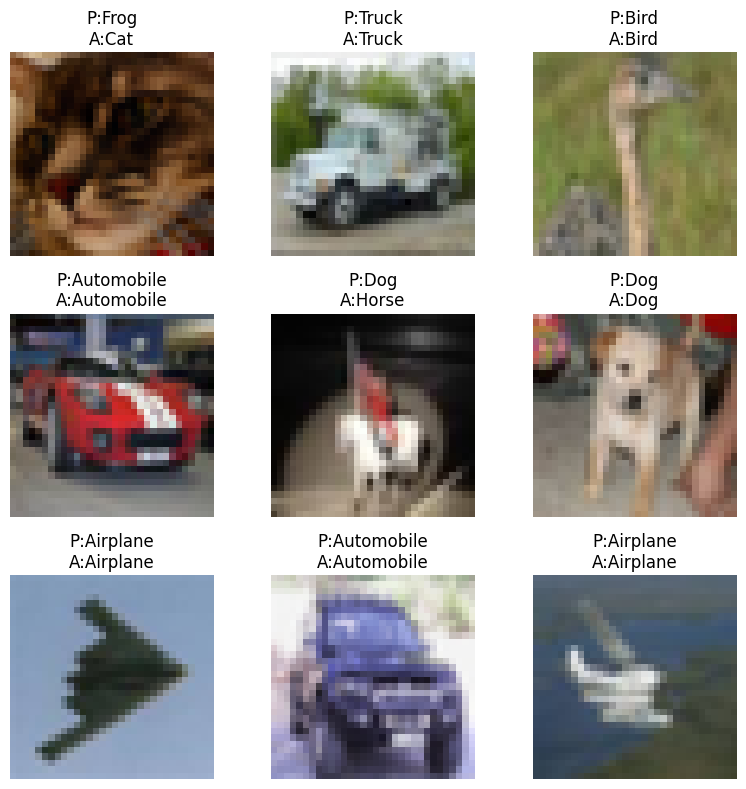

In [39]:
plt.figure(figsize = (8, 8))

indices = np.random.choice(
    len(X_test),
    9,
    replace = False
)

for i, index in enumerate(indices):

    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[index])
    plt.title(f"P:{classes[predictions[index]]}\nA:{classes[y_test[index]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()